In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/programmer3/credit-risk-dataset/credit_risk_dataset.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data 
# Note: Update the path if your Kaggle environment names the directory differently
file_path = '/kaggle/input/datasets/programmer3/credit-risk-dataset/credit_risk_dataset.csv' 
try:
    df = pd.read_csv(file_path)
    print("✅ Data successfully loaded!\n")
except FileNotFoundError:
    print("❌ Error: File not found. Check your Kaggle input directory.\n")

# Let's rename the target variable to 'bad_flag' to match your StrataScratch assignment
if 'credit_risk' in df.columns:
    df.rename(columns={'credit_risk': 'bad_flag'}, inplace=True)
elif 'loan_status' in df.columns:
    df.rename(columns={'loan_status': 'bad_flag'}, inplace=True)

# 2. Initial Sanity Check
print("--- SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- DATA TYPES & NON-NULL COUNTS ---")
print(df.info(), "\n")

print("--- MISSING VALUE SUMMARY ---")
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
if not missing_data.empty:
    print(missing_data)
    print(f"\nTotal columns with missing values: {len(missing_data)}")
else:
    print("No missing values detected (initially).")

print("\n--- TARGET VARIABLE IMBALANCE ('bad_flag') ---")
if 'bad_flag' in df.columns:
    print(df['bad_flag'].value_counts(normalize=True) * 100)
else:
    print("Target column 'bad_flag' not found. Please check column names.")

✅ Data successfully loaded!

--- SHAPE ---
Rows: 5000, Columns: 22

--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   employment_status           5000 non-null   object 
 4   annual_income               5000 non-null   float64
 5   account_age_months          5000 non-null   int64  
 6   avg_monthly_balance         5000 non-null   float64
 7   num_deposits_per_month      5000 non-null   int64  
 8   avg_deposit_amount          5000 non-null   float64
 9   debit_card_usage_frequency  5000 non-null   int64  
 10  debit_card_spending         5000 non-null   float64
 11  mobile_banking_logins       5000 non-null 

## Phase 2: Exploratory Data Analysis (EDA) & Data Integrity Checks
In this phase, we move beyond basic shape and type checks to look for 'hidden' messiness. 
Real-world data often disguises missing values as extreme numbers or generic strings. 

**Objectives:**
1. Check summary statistics for physical impossibilities (e.g., negative ages).
2. Inspect categorical columns for placeholder values (e.g., "Unknown").
3. Drop non-predictive identifiers.

In [5]:
# 1. Drop useless identifiers (Leakage / Overfitting risk)
if 'customer_id' in df.columns:
    df.drop('customer_id', axis=1, inplace=True)
    print("Dropped 'customer_id' column.\n")

# 2. Check for "Hidden" Missing Values in Numerical Columns
print("--- NUMERICAL SUMMARY STATISTICS ---")
# Transpose (.T) makes it easier to read when you have many columns
display(df.describe().T) 

# 3. Inspect Categorical Columns for weird placeholders
print("\n--- CATEGORICAL VALUE COUNTS ---")
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))

# 4. Quick Correlation Check against the Target
# This helps us see which numerical features actually matter for predicting 'bad_flag'
print("\n--- CORRELATION WITH TARGET ('bad_flag') ---")
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['bad_flag'].sort_values(ascending=False)
print(correlations)

Dropped 'customer_id' column.

--- NUMERICAL SUMMARY STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
age,5000.0,44.666600,14.384312,20.0,32.000000,45.000000,57.000000,69.000000
annual_income,5000.0,49870.073961,17831.984829,10000.0,37633.483896,49682.456590,61964.226233,113793.170197
account_age_months,5000.0,121.226800,68.325584,3.0,62.000000,120.500000,181.000000,239.000000
avg_monthly_balance,5000.0,1500.912691,772.243462,10.0,958.522753,1486.067085,2024.758900,4818.316040
num_deposits_per_month,5000.0,5.542000,3.424118,0.0,3.000000,6.000000,9.000000,11.000000
avg_deposit_amount,5000.0,800.663464,341.229714,20.0,559.312932,802.695763,1033.796072,1925.380969
debit_card_usage_frequency,5000.0,24.424800,14.395172,0.0,12.000000,25.000000,37.000000,49.000000
debit_card_spending,5000.0,500.284845,245.167842,0.0,328.342032,498.752458,664.056885,1379.491843
mobile_banking_logins,5000.0,39.028000,23.039457,0.0,19.000000,39.000000,58.000000,79.000000
online_transfer_frequency,5000.0,9.660600,5.858248,0.0,4.000000,10.000000,15.000000,19.000000



--- CATEGORICAL VALUE COUNTS ---

Value counts for gender:
gender
Female    1705
Other     1680
Male      1615
Name: count, dtype: int64

Value counts for employment_status:
employment_status
Employed         1746
Self-Employed    1633
Unemployed       1621
Name: count, dtype: int64

--- CORRELATION WITH TARGET ('bad_flag') ---
bad_flag                      1.000000
late_payment_count            0.483292
loan_default_history          0.181663
fraud_flag                    0.094890
debit_card_spending           0.019842
loan_application_amount       0.019492
account_age_months            0.017071
atm_withdrawal_frequency      0.017069
annual_income                 0.012743
num_deposits_per_month        0.009474
avg_deposit_amount            0.007921
total_outstanding_debt        0.007279
num_open_loans                0.007234
mobile_banking_logins         0.005100
avg_monthly_balance           0.003353
age                          -0.002969
online_transfer_frequency    -0.006969
debit_

## Phase 3: Feature Engineering & Preprocessing
To prepare for model benchmarking, we will:
1. **One-Hot Encode** categorical variables to convert them to numeric arrays.
2. **Isolate** the feature matrix (`X`) and target vector (`y`).
3. **Train/Test Split** using `stratify=y` to preserve our 76/24 imbalanced class distribution.
4. **Standardize** the numerical features so algorithms like Logistic Regression aren't biased by feature magnitude.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. One-Hot Encoding for Categoricals
# drop_first=True prevents the "dummy variable trap" (perfect multicollinearity)
df_encoded = pd.get_dummies(df, columns=['gender', 'employment_status'], drop_first=True)

# Convert boolean columns from get_dummies to integers (0 and 1) just to be clean
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

print(f"New feature count after encoding: {df_encoded.shape[1] - 1}\n")

# 2. Define Features (X) and Target (y)
X = df_encoded.drop('bad_flag', axis=1)
y = df_encoded['bad_flag']

# 3. Train-Test Split (with Stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print("\nVerifying Stratification (Training set target distribution):")
print(y_train.value_counts(normalize=True) * 100)

# 4. Feature Scaling
# We fit the scaler ONLY on the training data to prevent data leakage from the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only

# Convert back to DataFrame for readability later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n✅ Preprocessing complete. Data is scaled and ready for modeling.")

New feature count after encoding: 22

Training set size: 3750 rows
Testing set size: 1250 rows

Verifying Stratification (Training set target distribution):
bad_flag
1    76.586667
0    23.413333
Name: proportion, dtype: float64

✅ Preprocessing complete. Data is scaled and ready for modeling.


## Phase 4: Baseline Model Benchmarking
We will establish our baseline performance using Logistic Regression and a Random Forest Classifier. 
To handle the class imbalance natively, we apply `class_weight='balanced'`. 
We will evaluate the models using Scikit-learn's classification report and Yellowbrick's ROC-AUC visualizer to assess class separation capabilities.

--- LOGISTIC REGRESSION BASELINE ---
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       293
           1       0.95      0.90      0.93       957

    accuracy                           0.89      1250
   macro avg       0.84      0.88      0.86      1250
weighted avg       0.90      0.89      0.90      1250


--- RANDOM FOREST BASELINE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       293
           1       1.00      1.00      1.00       957

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250



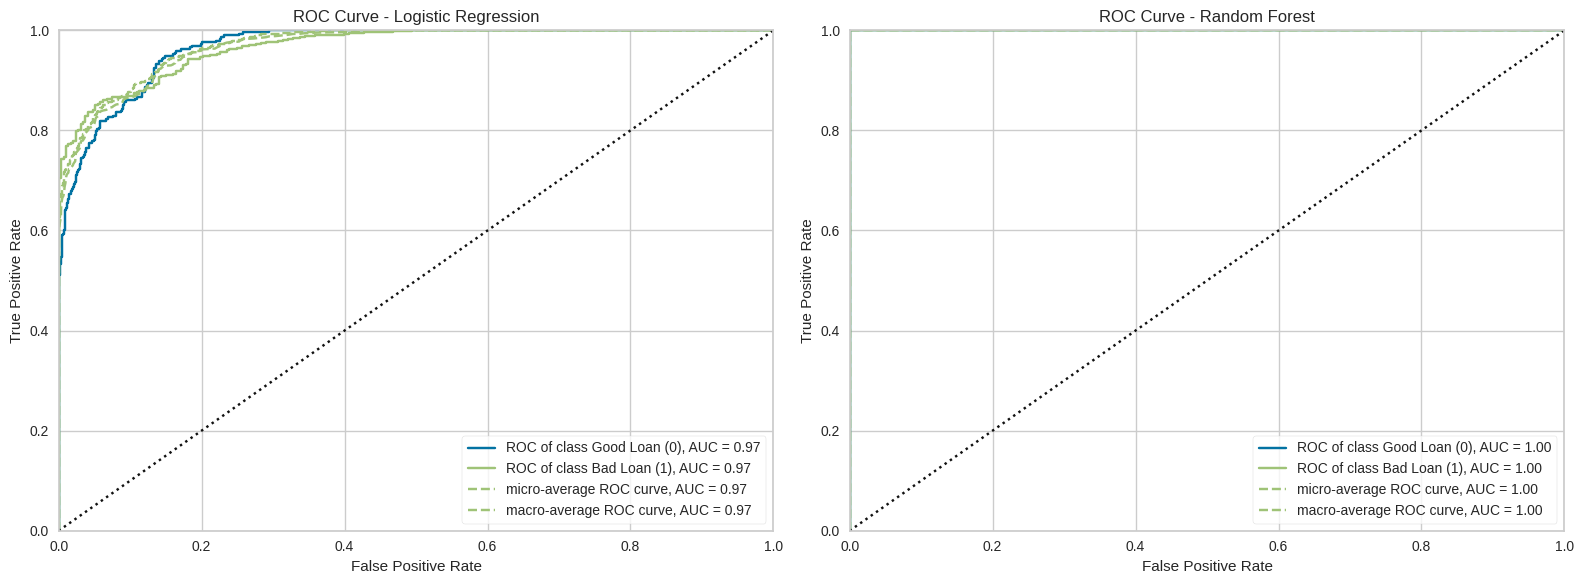

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from yellowbrick.classifier import ROCAUC
import matplotlib.pyplot as plt

# 1. Initialize our baseline models with class imbalance correction
# random_state ensures reproducibility
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

# 2. Train and text-evaluate Logistic Regression
print("--- LOGISTIC REGRESSION BASELINE ---")
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_log))

# 3. Train and text-evaluate Random Forest
print("\n--- RANDOM FOREST BASELINE ---")
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

# 4. Visual Evaluation with Yellowbrick (ROC-AUC)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Yellowbrick ROC for Logistic Regression
visualizer_log = ROCAUC(log_reg, ax=ax[0], classes=['Good Loan (0)', 'Bad Loan (1)'], title="ROC Curve - Logistic Regression")
visualizer_log.fit(X_train_scaled, y_train)
visualizer_log.score(X_test_scaled, y_test)
visualizer_log.finalize()

# Yellowbrick ROC for Random Forest
visualizer_rf = ROCAUC(rf_clf, ax=ax[1], classes=['Good Loan (0)', 'Bad Loan (1)'], title="ROC Curve - Random Forest")
visualizer_rf.fit(X_train_scaled, y_train)
visualizer_rf.score(X_test_scaled, y_test)
visualizer_rf.finalize()

plt.tight_layout()
plt.show()

## Phase 5: Hyperparameter Tuning (Optuna)
While our baseline Logistic Regression performed well, we will use Optuna to optimize its regularization strength (`C`). 
We optimize for `roc_auc` through 5-fold cross-validation to ensure the model's performance is stable across different subsets of our data.

In [8]:
import optuna
from sklearn.model_selection import cross_val_score

# 1. Define the Optuna Objective Function
def objective(trial):
    # We ask Optuna to test values for 'C' on a logarithmic scale
    c_param = trial.suggest_float('C', 1e-4, 10.0, log=True)
    
    # Initialize the model with the trial's parameter
    model = LogisticRegression(
        C=c_param,
        class_weight='balanced',
        solver='liblinear', # Robust solver for standard datasets
        random_state=42
    )
    
    # Evaluate using 5-fold Cross Validation on the training data
    # We use 'roc_auc' because of our imbalanced target
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

# 2. Create the study and run optimization
print("--- STARTING OPTUNA HYPERPARAMETER TUNING ---")
# We want to maximize the ROC-AUC score
study = optuna.create_study(direction='maximize')

# We'll run 20 trials. In a massive dataset, you might run 100+
study.optimize(objective, n_trials=20)

print("\n✅ OPTIMIZATION COMPLETE!")
print(f"Best Cross-Validated ROC-AUC: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

# 3. Train our final optimized model
best_c = study.best_params['C']
final_model = LogisticRegression(C=best_c, class_weight='balanced', solver='liblinear', random_state=42)
final_model.fit(X_train_scaled, y_train)

print("\nFinal Optimized Model successfully trained on the full training set.")

[I 2026-05-25 09:38:40,132] A new study created in memory with name: no-name-5b232fc0-d017-469e-8fd5-33be3bde9b16


--- STARTING OPTUNA HYPERPARAMETER TUNING ---


[I 2026-05-25 09:38:42,998] Trial 0 finished with value: 0.9758883407472698 and parameters: {'C': 1.0778276280106696}. Best is trial 0 with value: 0.9758883407472698.
[I 2026-05-25 09:38:43,070] Trial 1 finished with value: 0.974502823401413 and parameters: {'C': 0.019576251095123814}. Best is trial 0 with value: 0.9758883407472698.
[I 2026-05-25 09:38:43,142] Trial 2 finished with value: 0.9759339529823304 and parameters: {'C': 4.035765087924768}. Best is trial 2 with value: 0.9759339529823304.
[I 2026-05-25 09:38:43,193] Trial 3 finished with value: 0.9720630390712153 and parameters: {'C': 0.000921640363604044}. Best is trial 2 with value: 0.9759339529823304.
[I 2026-05-25 09:38:43,244] Trial 4 finished with value: 0.9726834238613984 and parameters: {'C': 0.0021060253004003353}. Best is trial 2 with value: 0.9759339529823304.
[I 2026-05-25 09:38:43,307] Trial 5 finished with value: 0.9758110528707771 and parameters: {'C': 0.5332749816853917}. Best is trial 2 with value: 0.97593395298


✅ OPTIMIZATION COMPLETE!
Best Cross-Validated ROC-AUC: 0.9759
Best Parameters: {'C': 9.951052680116813}

Final Optimized Model successfully trained on the full training set.


## Phase 6: Business Interpretation & Approval Scenarios
Instead of relying on a static 0.5 prediction threshold, we extract the predicted probabilities (`predict_proba`). 
We simulate various risk tolerance levels (Approval Thresholds) to show business stakeholders the direct trade-off between the Volume of Approved Loans and the Expected Default Rate of that portfolio.

In [9]:

import pandas as pd
from IPython.display import display

# 1. Extract the probability of class 1 (Bad Loan)
# predict_proba returns an array like [prob_class_0, prob_class_1]
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# 2. Create a DataFrame to analyze the test results
results_df = pd.DataFrame({
    'Actual_Bad_Flag': y_test,
    'Predicted_Risk_Score': y_pred_proba
})

# 3. Simulate different Business Approval Thresholds
# A threshold of 0.3 means: "Only approve loans if their risk score is UNDER 30%"
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
approval_scenarios = []

for thresh in thresholds:
    # Filter the portfolio to only include loans we would approve under this rule
    approved_portfolio = results_df[results_df['Predicted_Risk_Score'] < thresh]
    
    total_test_applicants = len(results_df)
    total_approved = len(approved_portfolio)
    
    if total_approved > 0:
        # Count how many of these "approved" loans actually defaulted in reality
        actual_defaults = approved_portfolio['Actual_Bad_Flag'].sum()
        
        # Calculate business metrics
        approval_rate = (total_approved / total_test_applicants) * 100
        portfolio_default_rate = (actual_defaults / total_approved) * 100
    else:
        approval_rate = 0
        portfolio_default_rate = 0
        
    approval_scenarios.append({
        'Max_Risk_Allowed': f"{int(thresh * 100)}%",
        'Total_Approved': total_approved,
        'Approval_Rate': f"{approval_rate:.1f}%",
        'Expected_Default_Rate': f"{portfolio_default_rate:.2f}%"
    })

# 4. Display the final business presentation table
scenario_df = pd.DataFrame(approval_scenarios)

print("--- LOAN PORTFOLIO SCENARIO ANALYSIS ---")
print("Reading the table: 'If the bank only accepts applicants with a risk score below X...' \n")
display(scenario_df)

--- LOAN PORTFOLIO SCENARIO ANALYSIS ---
Reading the table: 'If the bank only accepts applicants with a risk score below X...' 



,Max_Risk_Allowed,Total_Approved,Approval_Rate,Expected_Default_Rate
0,10%,211,16.9%,6.64%
1,20%,258,20.6%,13.95%
2,30%,291,23.3%,18.90%
3,40%,317,25.4%,23.34%
4,50%,345,27.6%,26.96%
5,60%,377,30.2%,31.03%
6,70%,416,33.3%,33.41%
7,80%,462,37.0%,38.53%
8,90%,521,41.7%,44.34%
